### Mount Google Drive

In [ ]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


### Check GPU Availability

In [ ]:
gpu_info = !nvidia-smi
gpu_info = '\n'.join(gpu_info)
if gpu_info.find('failed') >=0:
  print('Not connected to a GPU')
else:
  print(gpu_info)

Mon Mar  2 08:08:27 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   56C    P8             10W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

### Extracting 1st Dataset from ZIP

In [ ]:
import zipfile
import os

zip_path = "/content/drive/MyDrive/Dataset 526.zip"

extract_to = "/content/drowsiness_dataset_526"

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_to)

print(f"ZIP extracted to: {extract_to}")


ZIP extracted to: /content/drowsiness_dataset_526


In [ ]:
import pandas as pd
print(pd.read_csv("/content/drowsiness_dataset_526/train/_classes.csv").columns)

Index(['filename', ' awake', ' drowsy'], dtype='object')


### Converting Datasets From CSV to Proper Format

In [ ]:
import shutil
from tqdm import tqdm

# Organize images by class from CSVs
output_base = "/content/final_dataset"
splits = ["train", "valid", "test"]

for split in splits:
    csv_path = os.path.join(extract_to, split, "_classes.csv")
    images_path = os.path.join(extract_to, split)

    if not os.path.exists(csv_path):
        print(f"CSV not found for {split}: {csv_path}")
        continue

    df = pd.read_csv(csv_path)

    # Check for required columns
    expected_cols = ["filename", " awake", " drowsy"]
    if not all(col in df.columns for col in expected_cols):
        print(f" Missing expected columns in CSV: {csv_path}")
        print(f"Found columns: {list(df.columns)}")
        continue

    # Label: Drowsy if 'drowsy' == 1 else Non Drowsy
    def get_label(row):
        return "Drowsy" if row[" drowsy"] == 1 else "Non Drowsy"

    df["label"] = df.apply(get_label, axis=1)

    for _, row in tqdm(df.iterrows(), total=len(df), desc=f"Processing {split}"):
        filename = row["filename"]
        label = row["label"]

        src = os.path.join(images_path, filename)
        dest_dir = os.path.join(output_base, split, label)
        os.makedirs(dest_dir, exist_ok=True)

        dest = os.path.join(dest_dir, filename)

        try:
            shutil.copy(src, dest)
        except Exception as e:
            print(f"Failed to copy {src}: {e}")

print("\n All done! Images sorted by class in:", output_base)

Processing test: 100%|██████████| 71/71 [00:00<00:00, 2033.01it/s]


 All done! Images sorted by class in: /content/final_dataset


### Extraxt second dataset

In [ ]:
zip_path = "/content/drive/MyDrive/Dataset1448.zip"

extract_to = "/content/drowsiness_dataset_1448"

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_to)

print(f"ZIP extracted to: {extract_to}")


ZIP extracted to: /content/drowsiness_dataset_1448


In [ ]:
print(pd.read_csv("/content/drowsiness_dataset_1448/train/_classes.csv").columns)

Index(['filename', ' awake', ' drowsy'], dtype='object')


### Combine both dataset in proper format

In [ ]:
# Organize images by class from CSVs
output_base = "/content/final_dataset"
splits = ["train", "valid", "test"]

for split in splits:
    csv_path = os.path.join(extract_to, split, "_classes.csv")
    images_path = os.path.join(extract_to, split)

    if not os.path.exists(csv_path):
        print(f"CSV not found for {split}: {csv_path}")
        continue

    df = pd.read_csv(csv_path)

    # Check for required columns
    expected_cols = ["filename", " awake", " drowsy"]
    if not all(col in df.columns for col in expected_cols):
        print(f" Missing expected columns in CSV: {csv_path}")
        print(f"Found columns: {list(df.columns)}")
        continue

    # Label: Drowsy if 'drowsy' == 1 else Non Drowsy
    def get_label(row):
        return "Drowsy" if row[" drowsy"] == 1 else "Non Drowsy"

    df["label"] = df.apply(get_label, axis=1)

    for _, row in tqdm(df.iterrows(), total=len(df), desc=f"Processing {split}"):
        filename = row["filename"]
        label = row["label"]

        src = os.path.join(images_path, filename)
        dest_dir = os.path.join(output_base, split, label)
        os.makedirs(dest_dir, exist_ok=True)

        dest = os.path.join(dest_dir, filename)

        try:
            shutil.copy(src, dest)
        except Exception as e:
            print(f"Failed to copy {src}: {e}")

print("\n All done! Images sorted by class in:", output_base)

Processing test: 100%|██████████| 146/146 [00:00<00:00, 3129.45it/s]


 All done! Images sorted by class in: /content/final_dataset


### Create a final dataset with augmented images

In [ ]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator, img_to_array, load_img, array_to_img

input_base = "/content/final_dataset"
output_base = "/content/super_final_dataset"
splits = ["train", "valid", "test"]

augmenter = ImageDataGenerator(
    rotation_range=20,
    zoom_range=0.2,
    width_shift_range=0.1,
    height_shift_range=0.1,
    horizontal_flip=True,
    fill_mode='nearest'
)

for split in splits:
    for label in ["Drowsy", "Non Drowsy"]:
        input_dir = os.path.join(input_base, split, label)
        output_dir = os.path.join(output_base, split, label)
        os.makedirs(output_dir, exist_ok=True)

        image_files = os.listdir(input_dir)
        print(f"Augmenting {split}/{label}...")

        for img_name in tqdm(image_files, desc=f"{split}/{label}", leave=False):
            img_path = os.path.join(input_dir, img_name)

            try:
                img = load_img(img_path)
                x = img_to_array(img)
                x = x.reshape((1,) + x.shape)

                shutil.copy(img_path, os.path.join(output_dir, img_name))

                aug_iter = augmenter.flow(x, batch_size=1)
                aug_img = next(aug_iter)[0].astype('uint8')

                aug_img_pil = array_to_img(aug_img)
                aug_img_name = "aug_" + img_name
                aug_img_pil.save(os.path.join(output_dir, aug_img_name))

            except Exception as e:
                print(f"Error processing {img_name}: {e}")

print("\n All done! Augmented dataset created at:", output_base)


Augmenting train/Drowsy...


Augmenting train/Non Drowsy...


Augmenting valid/Drowsy...


Augmenting valid/Non Drowsy...


Augmenting test/Drowsy...


Augmenting test/Non Drowsy...



 All done! Augmented dataset created at: /content/super_final_dataset


### Converting the final dataset to zip

In [ ]:
import shutil

dataset_path = '/content/super_final_dataset'
zip_path = '/content/super_final_dataset.zip'

shutil.make_archive(base_name=zip_path.replace('.zip', ''), format='zip', root_dir=dataset_path)


'/content/super_final_dataset.zip'

### Saving the zip file to drive for direct import

In [ ]:
shutil.copy(zip_path, '/content/drive/MyDrive/super_final_dataset.zip')
print("Super Final Dataset zipped and saved to Drive ")


### Extract the final dataset directly without running above codes


In [ ]:
import zipfile
import os

zip_path = "/content/drive/MyDrive/super_final_dataset.zip"

extract_to = "/content/final_dataset"

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_to)

print(f"ZIP extracted to: {extract_to}")


ZIP extracted to: /content/final_dataset


### Importing Libraries

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras

# Reproducibility
tf.random.set_seed(3)
np.random.seed(3)

# Evaluation
from sklearn.metrics import confusion_matrix, classification_report
from collections import Counter

# Model & layers
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.models import Model
from tensorflow.keras.layers import (
    Dense,
    Dropout,
    GlobalAveragePooling2D,
    LayerNormalization
)

# Optimizers & callbacks
from tensorflow.keras.optimizers import Adam, SGD
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

In [ ]:
import sys
!{sys.executable} -m pip install mediapipe==0.10.20

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.0/61.0 kB 3.8 MB/s eta 0:00:00
INFO: pip is looking at multiple versions of jax to determine which version is compatible with other requirements. This could take a while.
INFO: pip is looking at multiple versions of opencv-contrib-python to determine which version is compatible with other requirements. This could take a while.
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 35.6/35.6 MB 58.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.0/18.0 MB 104.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 294.9/294.9 kB 32.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.8/2.8 MB 122.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 81.2/81.2 MB 11.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 69.1/69.1 MB 11.7 MB/s eta 0:00:00
  Attempting uninstall: protobuf
    Found existing installation: protobuf 5.29.6
    Uninstalling protobuf-5.29.6:
      Successfully uninstalled

In [ ]:
import mediapipe as mp
print("MediaPipe Installed Successfully ")

/usr/local/lib/python3.12/dist-packages/jaxlib/plugin_support.py:71: RuntimeWarning: JAX plugin jax_cuda12_plugin version 0.7.2 is installed, but it is not compatible with the installed jaxlib version 0.7.1, so it will not be used.
  warnings.warn(


MediaPipe Installed Successfully ✅


### Face Croping

In [ ]:
import os
import cv2
import mediapipe as mp
import numpy as np
from tqdm import tqdm

# CONFIGURATION
INPUT_DATASET = "/content/final_dataset"
OUTPUT_DATASET = "/content/final_dataset_faces"
IMG_SIZE = 224
SPLITS = ["train", "valid", "test"]
CLASSES = ["Drowsy", "Non Drowsy"]

# INITIALIZE MEDIAPIPE
mp_face = mp.solutions.face_detection
face_detector = mp_face.FaceDetection(
    model_selection=1,  # 0 = short range, 1 = full range
    min_detection_confidence=0.5
)

# FACE CROPPING FUNCTION
def crop_face_and_save(input_dir, output_dir):

    total_images = 0
    face_detected = 0

    for split in SPLITS:
        for cls in CLASSES:

            input_path = os.path.join(input_dir, split, cls)
            output_path = os.path.join(output_dir, split, cls)

            os.makedirs(output_path, exist_ok=True)

            if not os.path.exists(input_path):
                print(f"Skipping missing folder: {input_path}")
                continue

            for img_name in tqdm(os.listdir(input_path), desc=f"{split}-{cls}"):

                total_images += 1

                img_path = os.path.join(input_path, img_name)
                img = cv2.imread(img_path)

                if img is None:
                    continue

                img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
                h, w, _ = img.shape

                results = face_detector.process(img_rgb)

                # IF FACE DETECTED
                if results.detections:

                    detection = results.detections[0]
                    bbox = detection.location_data.relative_bounding_box

                    x1 = int(bbox.xmin * w)
                    y1 = int(bbox.ymin * h)
                    x2 = int((bbox.xmin + bbox.width) * w)
                    y2 = int((bbox.ymin + bbox.height) * h)

                    # Safety clipping
                    x1 = max(0, x1)
                    y1 = max(0, y1)
                    x2 = min(w, x2)
                    y2 = min(h, y2)

                    face = img[y1:y2, x1:x2]

                    if face.size != 0:
                        img = face
                        face_detected += 1

                # RESIZE (FACE OR ORIGINAL)
                img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))
                cv2.imwrite(os.path.join(output_path, img_name), img)

    # PRINT STATS
    print("\n========== PROCESS COMPLETED ==========")
    print("Total Images Processed:", total_images)
    print("Faces Successfully Detected:", face_detected)

    if total_images > 0:
        success_rate = (face_detected / total_images) * 100
        print("Face Detection Success Rate:", round(success_rate, 2), "%")

    print("Output Saved At:", OUTPUT_DATASET)


# RUN FUNCTION
crop_face_and_save(INPUT_DATASET, OUTPUT_DATASET)

# Release resources
face_detector.close()

test-Non Drowsy: 100%|██████████| 224/224 [00:04<00:00, 52.47it/s]


========== PROCESS COMPLETED ==========
Total Images Processed: 3948
Faces Successfully Detected: 3303
Face Detection Success Rate: 83.66 %
Output Saved At: /content/final_dataset_faces


In [ ]:
!zip -r /content/final_dataset_faces.zip /content/final_dataset_faces

  adding: content/final_dataset_faces/ (stored 0%)
  adding: content/final_dataset_faces/train/ (stored 0%)
  adding: content/final_dataset_faces/train/Drowsy/ (stored 0%)
  adding: content/final_dataset_faces/train/Drowsy/aug_571_jpg.rf.b1fb43e8cfe2d7057aa0260b886903bf.jpg (deflated 1%)
  adding: content/final_dataset_faces/train/Drowsy/aug_639_jpg.rf.0693abd9367c9ee17243bcae0128938a.jpg (deflated 1%)
  adding: content/final_dataset_faces/train/Drowsy/aug_450_jpg.rf.1f92a63fb53b23e150b294b2208aa093.jpg (deflated 1%)
  adding: content/final_dataset_faces/train/Drowsy/aug_564_jpg.rf.44a395361b12a17ead9533b8a1b7036c.jpg (deflated 1%)
  adding: content/final_dataset_faces/train/Drowsy/86_jpg.rf.d07da15f361216092f0f832553326316.jpg (deflated 1%)
  adding: content/final_dataset_faces/train/Drowsy/605_jpg.rf.e9b41905daa006414e8265c21d0fb6d5.jpg (deflated 1%)
  adding: content/final_dataset_faces/train/Drowsy/GOPR0492_MP4-293_jpg.rf.abcf7bdf07298d4430ec06702178fa11.jpg (deflated 1%)
  adding:

In [ ]:
from google.colab import files
files.download("/content/final_dataset_faces.zip")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

### Defining Dataset Paths

In [ ]:
train_dir = "/content/final_dataset_faces/train"
val_dir   = "/content/final_dataset_faces/valid"
test_dir  = "/content/final_dataset_faces/test"

### Image Preprocessing with `ImageDataGenerator`

These lines create data generators that automatically normalize image pixel values by scaling them from the range [0, 255] to [0, 1].

In [ ]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input

train_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    zoom_range=0.1,
    rotation_range=10,
    shear_range=5,
    brightness_range=[0.9, 1.1],
    horizontal_flip=True
)

val_datagen = ImageDataGenerator(preprocessing_function=preprocess_input)
test_datagen = ImageDataGenerator(preprocessing_function=preprocess_input)


### Creating Training Batches

In [ ]:
train_batches = train_datagen.flow_from_directory(
    train_dir,
    target_size=(224, 224),
    batch_size=16,
    class_mode='binary',
    shuffle=True
)

Found 2730 images belonging to 2 classes.


### Creating Testing Batches

In [ ]:
test_batches = test_datagen.flow_from_directory(
    test_dir,
    target_size=(224, 224),
    batch_size=16,
    class_mode='binary' ,
    shuffle=False
)

Found 434 images belonging to 2 classes.


### Creating Validation Batches

In [ ]:
val_batches = val_datagen.flow_from_directory(
    val_dir,
    target_size=(224, 224),
    batch_size=16,
    class_mode='binary',
    shuffle=False
)

Found 784 images belonging to 2 classes.


### Displaying Class Information

In [ ]:
from collections import Counter
train_class_indices = train_batches.class_indices
test_class_indices = test_batches.class_indices
val_class_indices = val_batches.class_indices

train_class_labels = train_batches.classes
test_class_labels = test_batches.classes
val_class_labels = val_batches.classes


train_class_counts = Counter(train_class_labels)
test_class_counts = Counter(test_class_labels)
val_class_counts = Counter(val_class_labels)

print("Class Names for train:\n", train_class_indices)
print("Class Counts for train:\n", train_class_counts)
print(end='\n')

print("Class Names for test:\n", test_class_indices)
print("Class Counts for test:\n", test_class_counts)
print(end='\n')

print("Class Names for validation :\n", val_class_indices)
print("Class Counts for validation:\n", val_class_counts)

Class Names for train:
 {'Drowsy': 0, 'Non Drowsy': 1}
Class Counts for train:
 Counter({1: 1430, 0: 1300})

Class Names for test:
 {'Drowsy': 0, 'Non Drowsy': 1}
Class Counts for test:
 Counter({1: 224, 0: 210})

Class Names for validation :
 {'Drowsy': 0, 'Non Drowsy': 1}
Class Counts for validation:
 Counter({1: 406, 0: 378})


### Visualizing Train, Test, Val Datasets

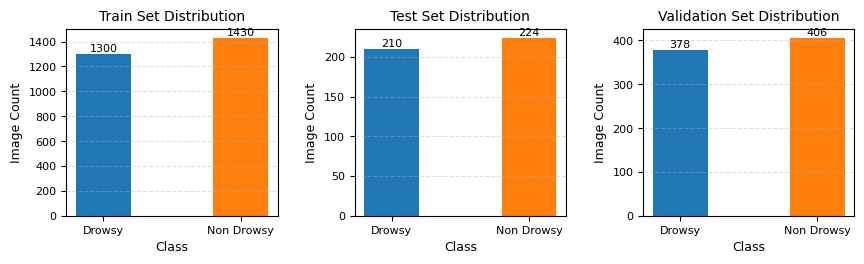

In [ ]:
import matplotlib.pyplot as plt
from collections import Counter

# Class index and label extraction
train_class_indices = train_batches.class_indices
test_class_indices = test_batches.class_indices
val_class_indices = val_batches.class_indices

train_class_labels = train_batches.classes
test_class_labels = test_batches.classes
val_class_labels = val_batches.classes

train_class_counts = Counter(train_class_labels)
test_class_counts = Counter(test_class_labels)
val_class_counts = Counter(val_class_labels)

# Mapping index to class name
idx_to_class = {v: k for k, v in train_class_indices.items()}

# Set up subplots: 1 row x 3 columns
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(9, 3))

def plot_subplot(ax, class_counts, title):
    class_names = [idx_to_class[i] for i in class_counts.keys()]
    values = list(class_counts.values())

    bars = ax.bar(class_names, values, color=['#1f77b4', '#ff7f0e'], width=0.4)
    ax.set_title(title, fontsize=10)
    ax.set_xlabel("Class", fontsize=9)
    ax.set_ylabel("Image Count", fontsize=9)
    ax.tick_params(axis='x', labelsize=8)
    ax.tick_params(axis='y', labelsize=8)
    ax.grid(axis='y', linestyle='--', alpha=0.4)

    # Add value labels on top of bars
    for bar in bars:
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.3,
                str(bar.get_height()), ha='center', va='bottom', fontsize=8)

# Individual subplots
plot_subplot(ax1, train_class_counts, "Train Set Distribution")
plot_subplot(ax2, test_class_counts, "Test Set Distribution")
plot_subplot(ax3, val_class_counts, "Validation Set Distribution")

plt.tight_layout(pad=2.0)
plt.savefig("class_distributions_separate.png", dpi=300, bbox_inches='tight')
plt.show()


### Loading Pre-trained Base Model (MobileNetV2)

In [ ]:
image_size = (224, 224)
base_model = MobileNetV2(
    weights='imagenet',
    include_top=False,
    input_shape=(image_size[0], image_size[1], 3),
)

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


### Freeze all layers except last 60

In [ ]:
# Freeze entire CNN
for layer in base_model.layers:
    layer.trainable = False

# Unfreeze deeper layers for better feature adaptation
for layer in base_model.layers[-60:]:
    layer.trainable = True

### Lightweight Transformer block to capture global facial relationships

In [ ]:
from tensorflow.keras.layers import (
    GlobalAveragePooling2D,
    LayerNormalization,
    MultiHeadAttention,
    Add,
    Reshape
)

def transformer_block(x, num_heads=4, key_dim=64):
    # Flatten spatial dimensions into tokens
    h, w, c = x.shape[1], x.shape[2], x.shape[3]
    x_tokens = Reshape((h * w, c))(x)

    # Self-attention
    attn_output = MultiHeadAttention(
        num_heads=num_heads,
        key_dim=key_dim
    )(x_tokens, x_tokens)

    # Residual connection + normalization
    x_tokens = Add()([x_tokens, attn_output])
    x_tokens = LayerNormalization()(x_tokens)

    # Restore spatial shape
    x = Reshape((h, w, c))(x_tokens)
    return x

### # CNN → Transformer → classification head for binary drowsiness prediction

In [ ]:
from tensorflow.keras.layers import Dense, Dropout

x = base_model.output
x = transformer_block(x)
x = GlobalAveragePooling2D()(x)
x = Dense(128, activation='relu')(x)
x = Dropout(0.4)(x)
predictions = Dense(1, activation='sigmoid')(x)

### # Balance drowsy and non-drowsy classes to prevent model bias

In [ ]:
from sklearn.utils import class_weight
class_weights = class_weight.compute_class_weight(
    class_weight='balanced',
    classes=np.unique(train_batches.classes),
    y=train_batches.classes
)
class_weights = dict(enumerate(class_weights))


### Creating the Final Model

In [ ]:
model = Model(inputs=base_model.input, outputs=predictions)

In [ ]:
model.compile(
    optimizer=Adam(learning_rate=5e-6),
    loss='binary_crossentropy',
    metrics=[
        'accuracy',
        tf.keras.metrics.AUC(name='auc')
    ]
)

In [ ]:
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

lr_reduce = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.3,
    patience=3,
    min_lr=1e-7,
    verbose=1
)

### Model Training

In [ ]:
history = model.fit(
    train_batches,
    validation_data=val_batches,
    epochs=30,
    callbacks=[early_stop, lr_reduce],
    class_weight=class_weights
)

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/30
171/171 ━━━━━━━━━━━━━━━━━━━━ 111s 418ms/step - accuracy: 0.5253 - auc: 0.5673 - loss: 0.7132 - val_accuracy: 0.5714 - val_auc: 0.6346 - val_loss: 0.6931 - learning_rate: 5.0000e-06
Epoch 2/30
171/171 ━━━━━━━━━━━━━━━━━━━━ 41s 239ms/step - accuracy: 0.6814 - auc: 0.7600 - loss: 0.5866 - val_accuracy: 0.6773 - val_auc: 0.7775 - val_loss: 0.5933 - learning_rate: 5.0000e-06
Epoch 3/30
171/171 ━━━━━━━━━━━━━━━━━━━━ 41s 239ms/step - accuracy: 0.7901 - auc: 0.8688 - loss: 0.4730 - val_accuracy: 0.7832 - val_auc: 0.8642 - val_loss: 0.4894 - learning_rate: 5.0000e-06
Epoch 4/30
171/171 ━━━━━━━━━━━━━━━━━━━━ 41s 237ms/step - accuracy: 0.8242 - auc: 0.9074 - loss: 0.3988 - val_accuracy: 0.8584 - val_auc: 0.9177 - val_loss: 0.3798 - learning_rate: 5.0000e-06
Epoch 5/30
171/171 ━━━━━━━━━━━━━━━━━━━━ 40s 231ms/step - accuracy: 0.8688 - auc: 0.9410 - loss: 0.3191 - val_accuracy: 0.8699 - val_auc: 0.9439 - val_loss: 0.3132 - learning_rate: 5.0000e-06
Epoch 6/30
171/171 ━━━━━━━━━━━━━━━━━━━━ 40s 

### Saving the Trained Model
- **Purpose**: Allows reloading the model later without retraining.

In [ ]:
model.save('/content/drive/MyDrive/ModelCNNTransformer.keras')

### Loading the Saved Model

In [ ]:
from tensorflow.keras.models import load_model

model = load_model("/content/drive/MyDrive/CNNTransformer.keras")

### Evaluating Model on Training Data

In [ ]:
train_loss, train_accuracy, train_auc = model.evaluate(train_batches,verbose=1)

print(f"Training Loss: {train_loss:.4f}")
print(f"Training Accuracy: {train_accuracy*100:.2f}%")
print(f"Training AUC: {train_auc:.4f}")

171/171 ━━━━━━━━━━━━━━━━━━━━ 41s 238ms/step - accuracy: 0.9873 - auc: 0.9995 - loss: 0.0353
Training Loss: 0.0348
Training Accuracy: 98.83%
Training AUC: 0.9995


### Evaluating Model on Testing Data

In [ ]:
test_loss, test_accuracy, test_auc = model.evaluate(test_batches)

print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_accuracy*100:.2f}%")
print(f"Test AUC: {test_auc:.4f}")

28/28 ━━━━━━━━━━━━━━━━━━━━ 13s 489ms/step - accuracy: 0.9480 - auc: 0.5435 - loss: 0.1974
Test Loss: 0.1676
Test Accuracy: 94.24%
Test AUC: 0.9830


### Evaluating Model on Validation data

In [ ]:
val_loss, val_accuracy, val_auc = model.evaluate(val_batches)

print(f"Validation Loss: {val_loss:.4f}")
print(f"Validation Accuracy: {val_accuracy*100:.2f}%")
print(f"Validation AUC: {val_auc:.4f}")

49/49 ━━━━━━━━━━━━━━━━━━━━ 2s 29ms/step - accuracy: 0.9572 - auc: 0.5354 - loss: 0.1381
Validation Loss: 0.1188
Validation Accuracy: 95.79%
Validation AUC: 0.9897


In [ ]:
test_batches.reset()

### Predicting Test Labels

In [ ]:
import numpy as np

steps = int(np.ceil(test_batches.samples / test_batches.batch_size))

y_pred = model.predict(
    test_batches,
    steps=steps,
    verbose=1
)

y_pred_labels = (y_pred > 0.5).astype(int).flatten()

28/28 ━━━━━━━━━━━━━━━━━━━━ 12s 252ms/step


### Getting Actual Test Labels

In [ ]:
y_true = test_batches.classes

### Confusion Matrix

In [ ]:
from sklearn.metrics import confusion_matrix

# Ground truth (safe & documented)
y_true = test_batches.classes

conf_matrix = confusion_matrix(y_true, y_pred_labels)
print(conf_matrix)

[[198  12]
 [ 13 211]]


In [ ]:
print(len(y_true), len(y_pred_labels))

434 434


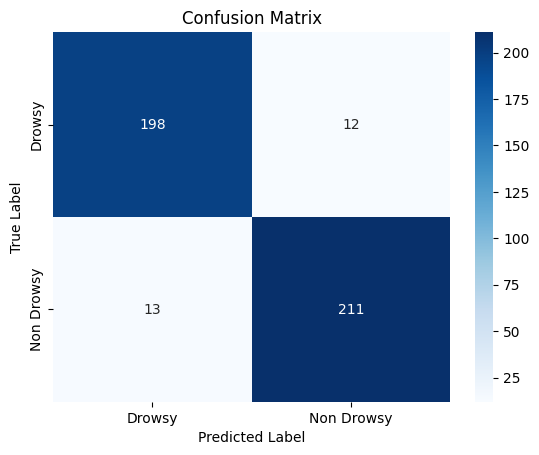

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.heatmap(
    conf_matrix,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Drowsy", "Non Drowsy"],
    yticklabels=["Drowsy", "Non Drowsy"]
)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix")
plt.show()

### Classification Report

In [ ]:
from sklearn.metrics import classification_report

# Correct ground truth
y_true = test_batches.classes

report = classification_report(
    y_true,
    y_pred_labels,
    target_names=['Drowsy', 'Non Drowsy']
)

print(report)

              precision    recall  f1-score   support

      Drowsy       0.94      0.94      0.94       210
  Non Drowsy       0.95      0.94      0.94       224

    accuracy                           0.94       434
   macro avg       0.94      0.94      0.94       434
weighted avg       0.94      0.94      0.94       434

